# lrdata to MuData

### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wr

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
data_path = Path("../../data/agne_cd/")
adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

In [4]:
adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

In [5]:
adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


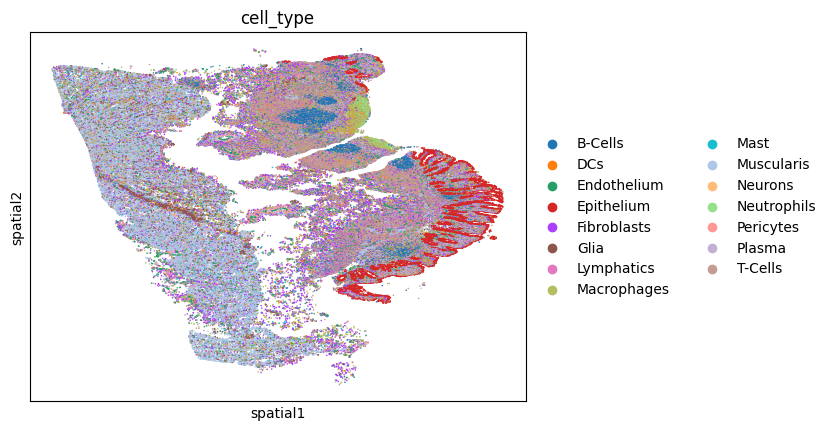

In [6]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s= 5)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=50)

#### Visualize proximity

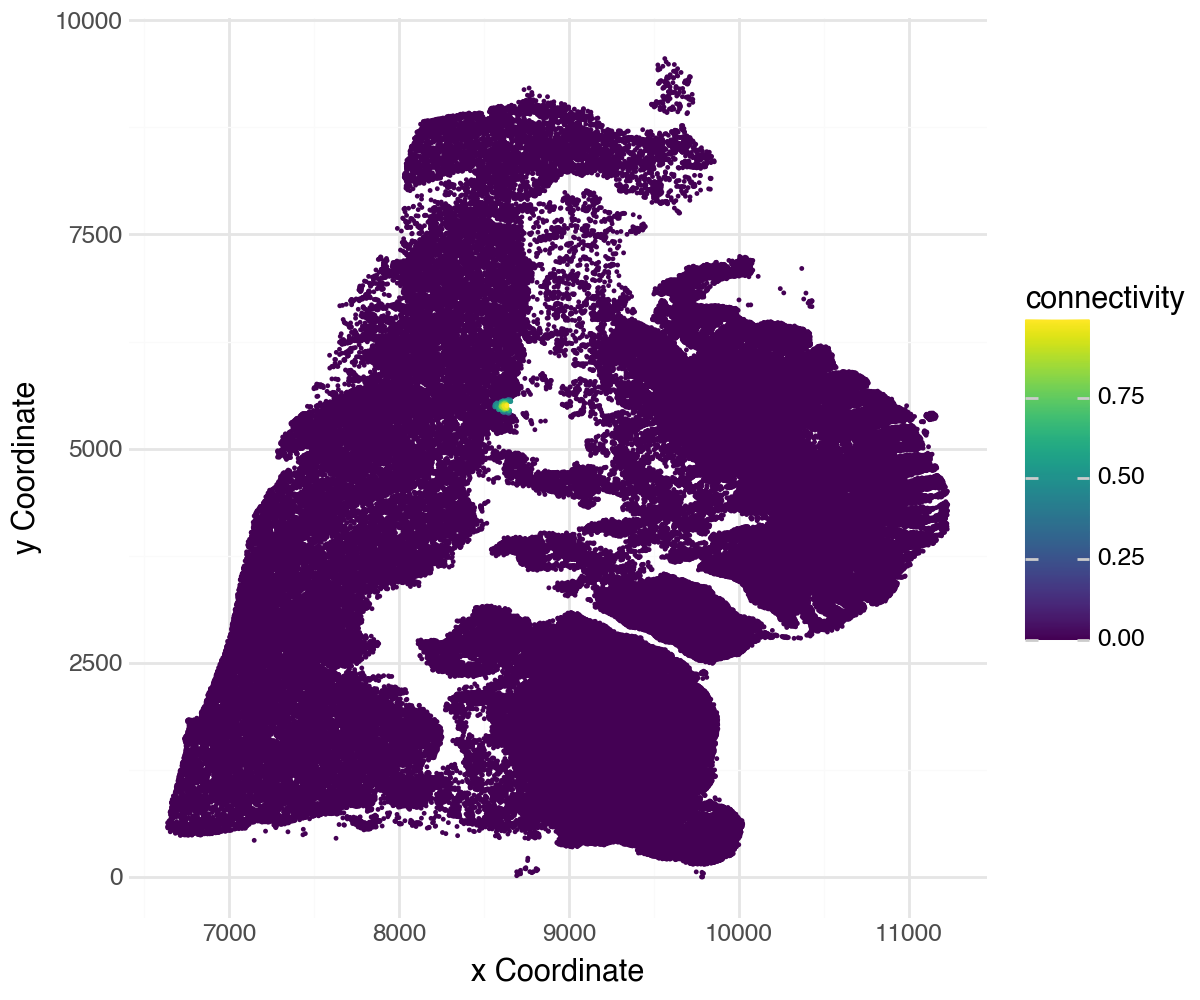

In [8]:
li.pl.connectivity(adata, idx=5500, size=0.01, figure_size=(6, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [9]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [10]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
IL1B,0.456484,0.000000,1.115748e-07,0.000000
REG1A,0.440240,0.000000,1.115748e-07,0.000000
HCAR3,0.436297,0.000000,1.115748e-07,0.000000
OLFM4,0.424013,0.000000,1.115748e-07,0.000000
REG1B,0.406739,0.000000,1.115748e-07,0.000000
...,...,...,...,...
IL23A,-0.000443,0.094852,1.115748e-07,0.107356
INCA1,-0.000465,0.084274,1.115748e-07,0.095766
CCDC103,-0.000478,0.078311,1.115748e-07,0.089208
GRM2,-0.000496,0.070686,1.115748e-07,0.080757


### Filter by spatially variable genes (SVGs)

In [11]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1543

In [12]:
adata = adata[:, svgs]

## Compute inflow score 

#### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [13]:
lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource_name='consensus',
                      use_raw=False)
                                  
lrdata.shape

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/b260-admin/Repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(191794, 6293)

### Optional: filter data to keep only spatially variable LR interaction

In [14]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [15]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

5139

In [16]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
Neutrophils^CSF1^CSF3R,0.387629,0.0,1.115748e-07,0.0
Macrophages^LPL^CD44,0.390192,0.0,1.115748e-07,0.0
Macrophages^LAMB3^CD44,0.392895,0.0,1.115748e-07,0.0
B-Cells^CD22^PTPRC,0.398515,0.0,1.115748e-07,0.0
B-Cells^ST6GAL1^CD22,0.406828,0.0,1.115748e-07,0.0
DCs^SPP1^CD44,0.417148,0.0,1.115748e-07,0.0
B-Cells^CXCL12^CXCR4,0.421053,0.0,1.115748e-07,0.0
Macrophages^SPP1^CD44,0.430241,0.0,1.115748e-07,0.0
B-Cells^C3^CD19,0.465401,0.0,1.115748e-07,0.0
B-Cells^CXCL14^CXCR4,0.465569,0.0,1.115748e-07,0.0


### Convert lrdata to muData

In [18]:
import scanpy as sc
import mudata as md
import anndata as an

from liana._constants import DefaultValues as V

from liana._docs import d
from liana._logging import _logg


def anndata_to_mdata(
    adata,
    groupby,
    min_cells,
    lr_sep,
    by_var,
    verbose,

):
    """
    Convert AnnData object to MultiData object.

    Args:
    ----------
    %(adata)s
    %(groupby)s
    %(min_cells)s
    by_var: bool, optional
        Whether to group by variables instead of observations. Default is False.
    %(lr_sep)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object.
    """

    adata_dict = {}

    if by_var:
        # Extract modalities from variable name prefixes before the `lr_sep` separator
        modalities = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from var): {modality}")

            # Filter variables (genes) belonging to the current modality
            var_filter = adata.var.index.str.startswith(f"{modality}{lr_sep}")
            adata_mod = adata[:, var_filter].copy()

            # Apply gene filtering within this modality
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)

            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from var): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    else:
        # Extract modalities from the observation annotation based on `groupby`
        modalities = adata.obs[groupby].unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from obs): {modality}")

            # Filter observations (cells) belonging to the current modality
            adata_mod = adata[adata.obs[groupby] == modality].copy()

            # Apply gene filtering
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)


            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from obs): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    # Create and return a MuData object with filtered modalities
    mudata = md.MuData(adata_dict)
    return mudata
        

In [19]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [20]:
lrdata

View of AnnData object with n_obs × n_vars = 191794 × 5139
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
    var: 'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
    uns: 'cell_type_colors', 'moranI'
    obsm: 'X_umap', 'spatial'
    obsp: 'spatial_connectivities'

In [21]:
mdata = anndata_to_mdata(
    adata = lrdata,
    groupby = "cell_type",
    min_cells=10,
    lr_sep = "^",
    by_var = True,
    verbose = True
    )

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [22]:
mdata

MuData object with n_obs × n_vars = 191794 × 4935
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  15 modalities
    B-Cells:	191794 x 297
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Macrophages:	191794 x 398
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    DCs:	191794 x 378
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neutrophils:	191794 x 194
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Lymphatics:	191794 x 348
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neurons:	191794 x 157
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Fibroblasts:	191794 x 403
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    T-Cells:	191794 x 377
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Plasma:	191794 x 368
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Muscularis:	191794 x 350
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Glia:	191794 x 332
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', '

In [23]:
mdata.mod['Endothelium'].var

,mean,variance,std,cv,nonzero_fraction,n_cells
Endothelium^SPP1^CD44,0.009286,0.006655,0.081575,8.785078,0.024719,4741
Endothelium^LAMB3^CD44,0.000513,0.000154,0.012412,24.196619,0.002357,452
Endothelium^CD22^PTPRC,0.000777,0.000173,0.013157,16.940613,0.003905,749
Endothelium^NTN1^MCAM,0.001281,0.000540,0.023231,18.136559,0.004442,852
Endothelium^LGALS9^PTPRC,0.011162,0.004065,0.063758,5.712034,0.041988,8053
...,...,...,...,...,...,...
Endothelium^CD99^PILRA,0.001962,0.001494,0.038652,19.695659,0.004484,860
Endothelium^LAMC1^ITGA6_ITGB4,0.000605,0.000250,0.015821,26.142881,0.002351,451
Endothelium^NECTIN2^TIGIT,0.000927,0.000369,0.019204,20.721205,0.003420,656
Endothelium^CCL22^CCR4,0.000014,0.000003,0.001594,116.349167,0.000078,15


### Filter out modalities if ncells < 10 and/or ngenes <10

In [25]:
for mod_name, adatas in mdata.mod.items():
    cells, genes = adatas.shape  
    print(f"Modality: {mod_name}, Cells: {cells}, Interactions: {genes}")

Modality: B-Cells, Cells: 191794, Interactions: 297
Modality: Macrophages, Cells: 191794, Interactions: 398
Modality: DCs, Cells: 191794, Interactions: 378
Modality: Neutrophils, Cells: 191794, Interactions: 194
Modality: Lymphatics, Cells: 191794, Interactions: 348
Modality: Neurons, Cells: 191794, Interactions: 157
Modality: Fibroblasts, Cells: 191794, Interactions: 403
Modality: T-Cells, Cells: 191794, Interactions: 377
Modality: Plasma, Cells: 191794, Interactions: 368
Modality: Muscularis, Cells: 191794, Interactions: 350
Modality: Glia, Cells: 191794, Interactions: 332
Modality: Pericytes, Cells: 191794, Interactions: 345
Modality: Epithelium, Cells: 191794, Interactions: 306
Modality: Mast, Cells: 191794, Interactions: 318
Modality: Endothelium, Cells: 191794, Interactions: 364


In [26]:
filtered_mods = {key: adata for key, adata in mdata.mod.items() if adata.shape[0] >= 10 and adata.shape[1] >= 10}
mdata.mod = filtered_mods

### Add global obs

In [28]:
mdata.obs = pd.DataFrame(index=mdata.obs_names)
mdata.var = pd.DataFrame(index=mdata.var_names)
mdata.obsm = {}
mdata.varm = {}

In [29]:
mdata.obsm = adata.obsm
mdata.uns = adata.uns

In [30]:
# for modality in mdata.mod:
#     #mdata.mod[modality].obs = pd.DataFrame(index=mdata.mod[modality].obs_names)
#     #mdata.mod[modality].var = pd.DataFrame(index=mdata.mod[modality].var_names)
#     #mdata.mod[modality].obsm = {}
#     mdata.mod[modality].uns = {}
#     mdata.mod[modality].obsp = {}

In [31]:
# adata.obs = adata.obs.reindex(mdata.obs_names)
# mdata.obs = adata.obs

In [32]:
# mdata

### Save mdata

In [33]:
mdata.write_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


# Run MOFA-Flex

In [34]:
import mudata as md
import mofaflex as mfl

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [35]:
mdata = md.read_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [36]:
mdata

MuData object with n_obs × n_vars = 191794 × 4935
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  uns:	'cell_type_colors', 'moranI'
  obsm:	'X_umap', 'spatial'
  15 modalities
    B-Cells:	191794 x 297
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Macrophages:	191794 x 398
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    DCs:	191794 x 378
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neutrophils:	191794 x 194
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Lymphatics:	191794 x 348
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Neurons:	191794 x 157
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Fibroblasts:	191794 x 403
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    T-Cells:	191794 x 377
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Plasma:	191794 x 368
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Muscularis:	191794 x 350
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'cell_type_colors', 'moranI'
      obsm:	'X_umap', 'spatial'
      obsp:	'spatial_connectivities'
    Gli

In [39]:
?mfl.TrainingOptions

Init signature:
mfl.TrainingOptions(
    *,
    device: str | torch.device = 'cuda',
    batch_size: int = 0,
    max_epochs: int = 10000,
    n_particles: int = 1,
    lr: float = 0.001,
    early_stopper_patience: int = 100,
    save_path: pathlib._local.Path | str | None = None,
    mofa_compat: Union[Literal['full', 'modelonly'], bool] = False,
    seed: int | None = None,
    num_workers: int = 0,
    pin_memory: bool = False,
) -> None
Docstring:      Options for training.
File:           ~/miniforge3/envs/liana313/lib/python3.13/site-packages/mofaflex/_core/mofaflex.py
Type:           type
Subclasses:     

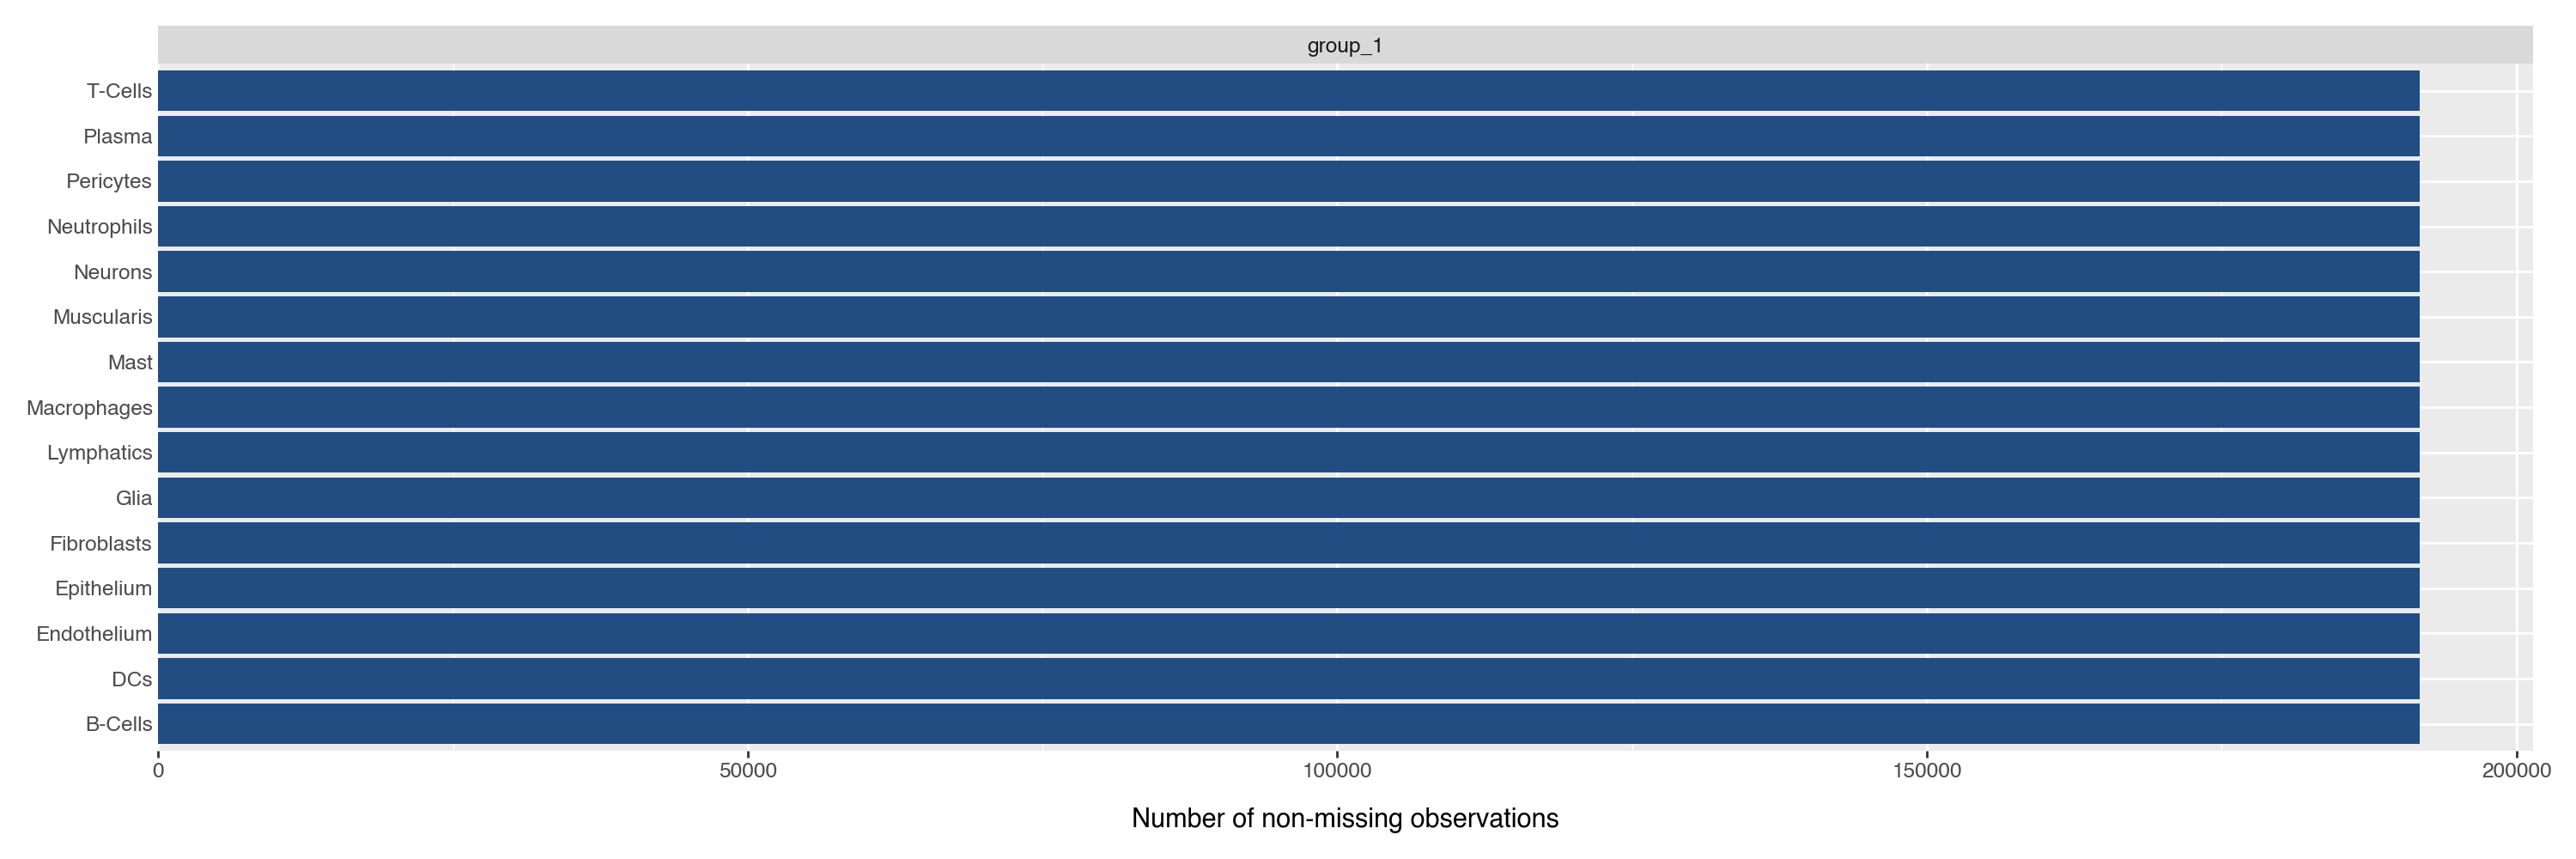

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. 

KeyboardInterrupt: 

In [45]:
model = mfl.MOFAFLEX(
    mdata,
    mfl.DataOptions(covariates_obsm_key="spatial"),
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="GP",
        likelihoods="Normal",
        weight_prior="SnS",
        nonnegative_factors=True,
        nonnegative_weights=True,
    ),
    mfl.TrainingOptions(
        batch_size=1000,
        n_particles=1,
        lr=0.005,
        max_epochs=100,
        save_path=str("model_sns_gp_C57BL6J_2.039.hdf5"),
        early_stopper_patience=50,
        device='mps'
    ),
)

# Model Overview

In [ ]:
#Load mofa model
model = mfl.MOFAFLEX.load("model_sns_gp_C57BL6J_2.039.hdf5")

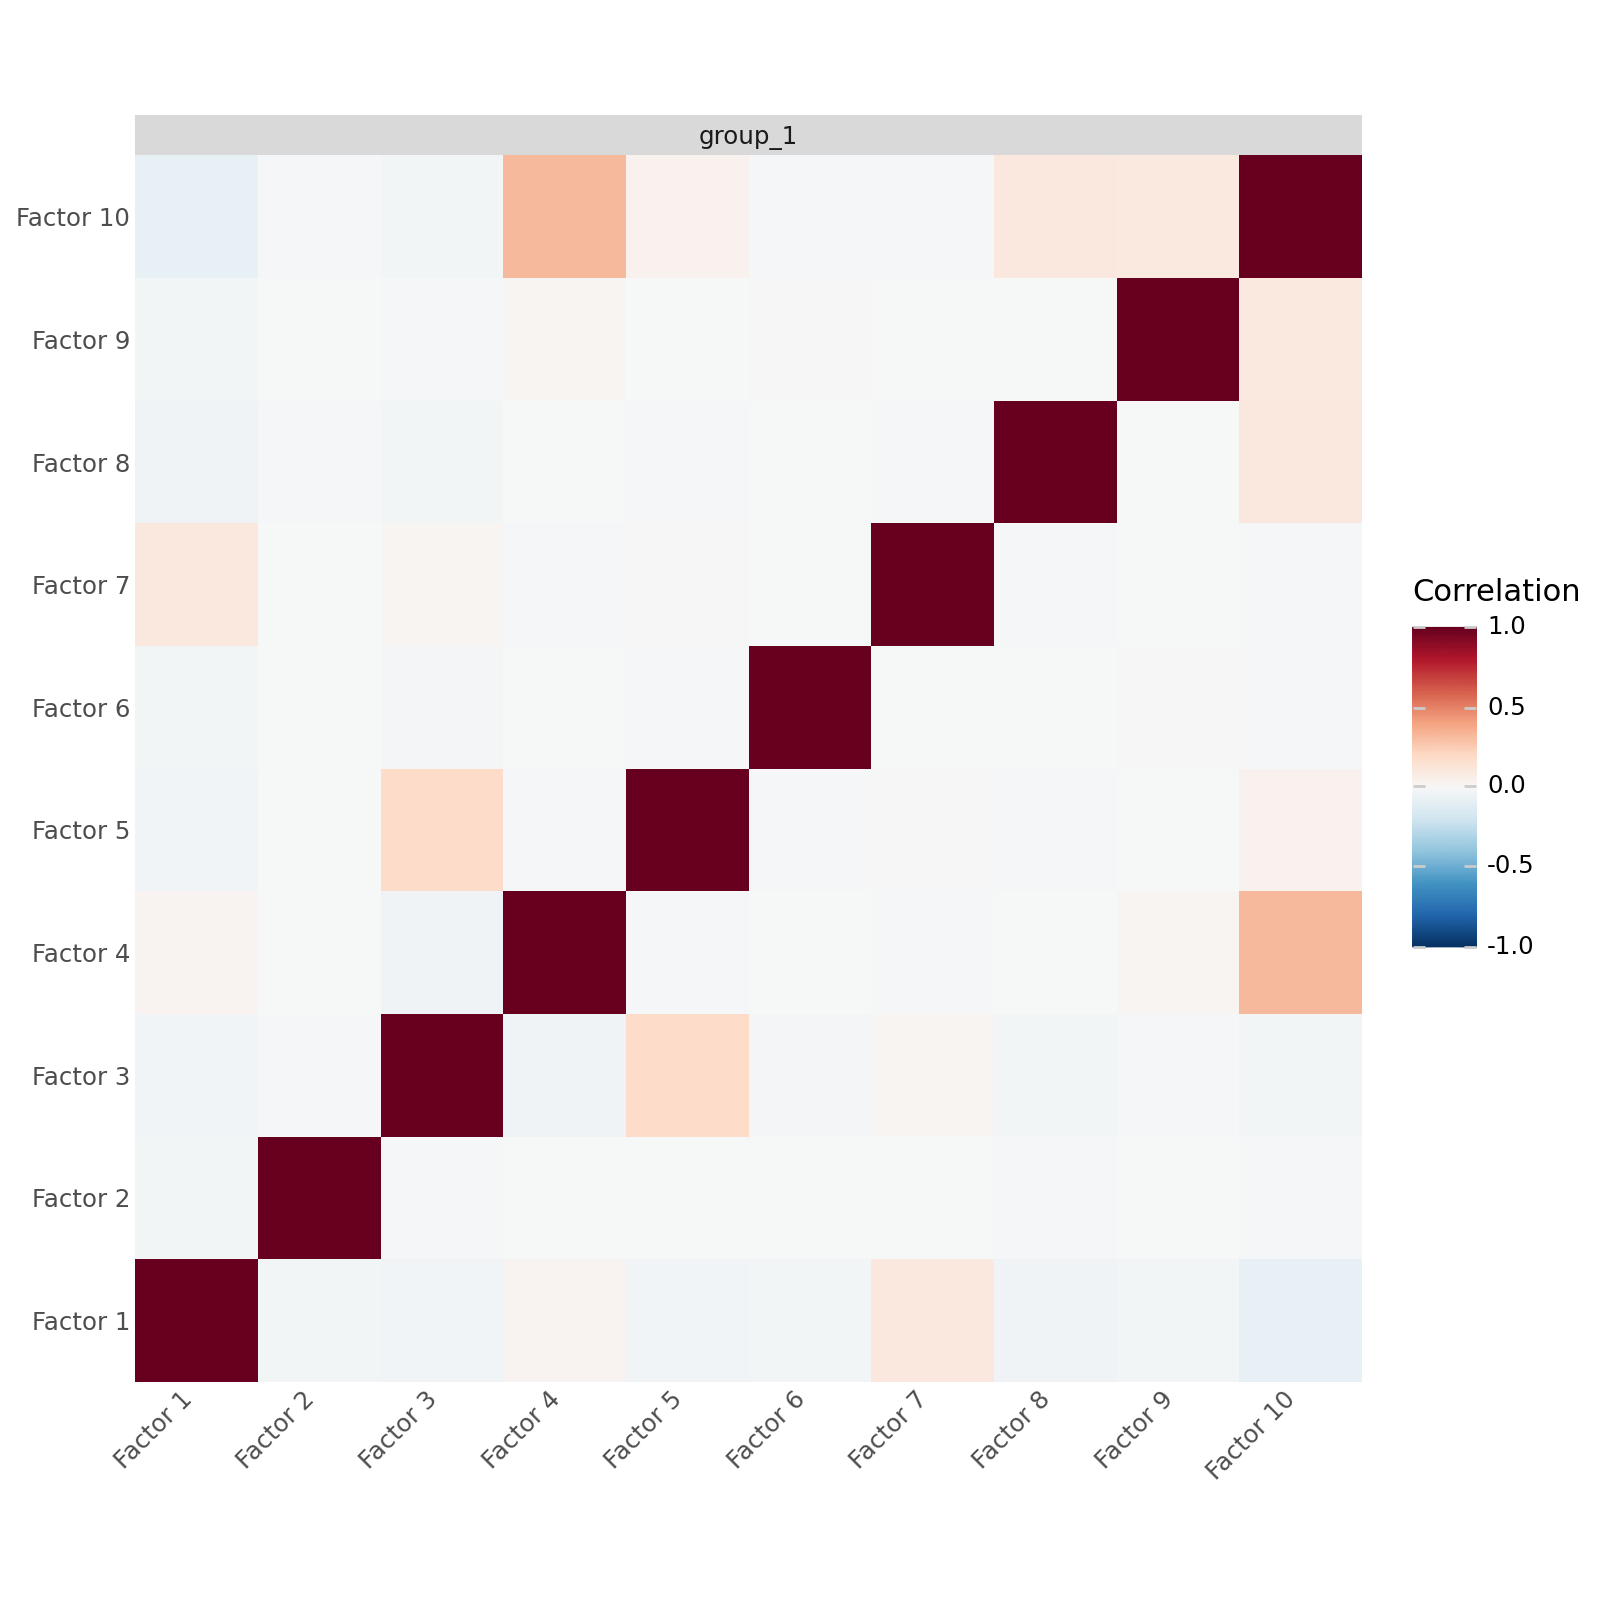

In [ ]:
#Factor correlation
mfl.pl.factor_correlation(model)